# **Code Analysis Process**

In [ ]:
#Imports and Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import random
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from imgaug import augmenters as iaa

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

print("All libraries imported successfully.")
print(f"TensorFlow Version: {tf.__version__}")

c:\Users\LENOVO\anaconda3\envs\drive39\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


All libraries imported successfully.
TensorFlow Version: 2.10.0


## STEP 1 : Importing data and Exploration

In [ ]:
#Import Data
def importDataInfo(path):
    columns = ['Center', 'Left', 'Right', 'Steering', 'Throttle', 'Brake', 'Speed']
    data = pd.read_csv(os.path.join(path, 'driving_log.csv'), names=columns)
    # Clean paths if needed (removes 'C:\...' prefix if present)
    data['Center'] = data['Center'].apply(lambda x: x.split('\\')[-1])
    data['Left'] = data['Left'].apply(lambda x: x.split('\\')[-1])
    data['Right'] = data['Right'].apply(lambda x: x.split('\\')[-1])
    return data

path = 'myData'
data = importDataInfo(path)

print(f"Total Imported Images: {data.shape[0]}")
data.head() # Shows the first 5 rows of your dataframe

Total Imported Images: 8208


,Center,Left,Right,Steering,Throttle,Brake,Speed
0,center_2025_12_21_20_29_44_896.jpg,left_2025_12_21_20_29_44_896.jpg,right_2025_12_21_20_29_44_896.jpg,0.0,0.057998,0.0,0.001129
1,center_2025_12_21_20_29_44_997.jpg,left_2025_12_21_20_29_44_997.jpg,right_2025_12_21_20_29_44_997.jpg,0.0,0.360663,0.0,0.314476
2,center_2025_12_21_20_29_45_097.jpg,left_2025_12_21_20_29_45_097.jpg,right_2025_12_21_20_29_45_097.jpg,0.0,0.661962,0.0,0.951190
3,center_2025_12_21_20_29_45_198.jpg,left_2025_12_21_20_29_45_198.jpg,right_2025_12_21_20_29_45_198.jpg,0.0,0.965194,0.0,1.922999
4,center_2025_12_21_20_29_45_298.jpg,left_2025_12_21_20_29_45_298.jpg,right_2025_12_21_20_29_45_298.jpg,0.0,1.000000,0.0,3.077947


## STEP2 : Data Balancing

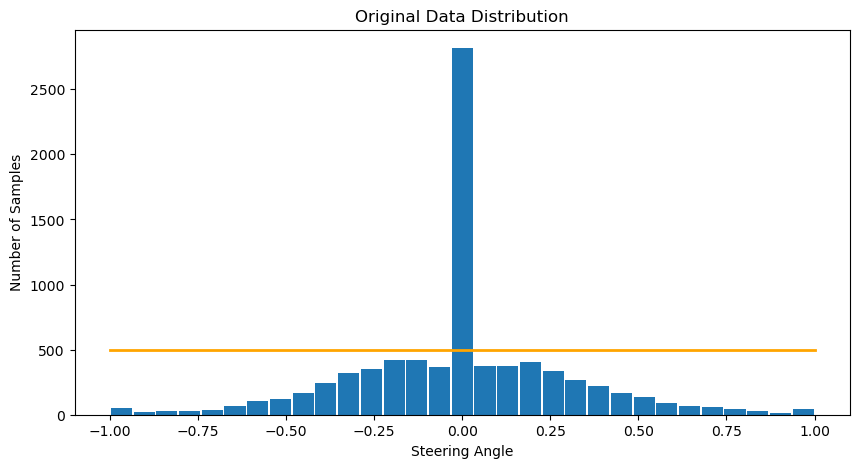

Removed Images: 2316
Remaining Images: 5892


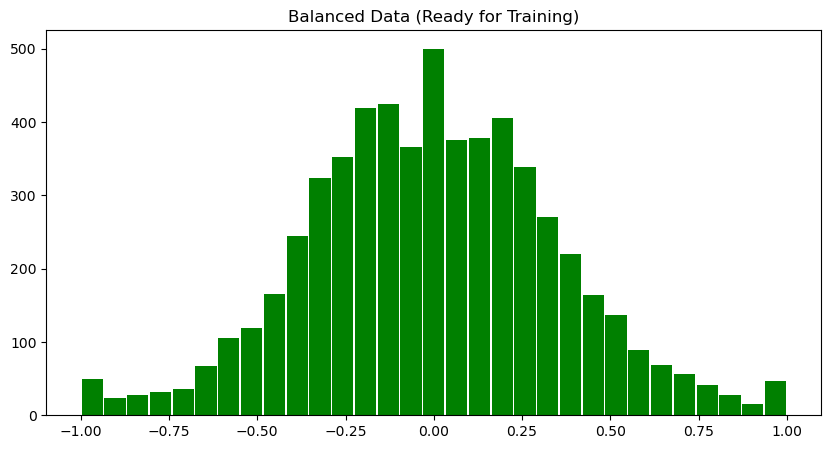

In [ ]:
# Balance Data Visualization
def balanceData(data, display=True):
    nBin = 31
    samplesPerBin = 500 # The "Goldilocks" number we found
    hist, bins = np.histogram(data['Steering'], nBin)
    
    if display:
        center = (bins[:-1] + bins[1:]) * 0.5
        plt.figure(figsize=(10,5))
        plt.bar(center, hist, width=0.06)
        plt.plot((np.min(data['Steering']), np.max(data['Steering'])), (samplesPerBin, samplesPerBin), color='orange', linewidth=2)
        plt.title('Original Data Distribution')
        plt.xlabel('Steering Angle')
        plt.ylabel('Number of Samples')
        plt.show()
    
    # Pruning the data
    removeindexList = []
    for j in range(nBin):
        binDataList = []
        for i in range(len(data['Steering'])):
            if data['Steering'][i] >= bins[j] and data['Steering'][i] <= bins[j + 1]:
                binDataList.append(i)
        binDataList = shuffle(binDataList)
        binDataList = binDataList[samplesPerBin:]
        removeindexList.extend(binDataList)
    
    print('Removed Images:', len(removeindexList))
    data.drop(data.index[removeindexList], inplace=True)
    print('Remaining Images:', len(data))
    
    if display:
        hist, _ = np.histogram(data['Steering'], nBin)
        plt.figure(figsize=(10,5))
        plt.bar(center, hist, width=0.06, color='green')
        plt.title('Balanced Data (Ready for Training)')
        plt.show()
    return data

data = balanceData(data, display=True)

## Step3 : Preparing Lists for Training

In [ ]:
# Load Data Lists
def loadData(path, data):
    imagesPath = []
    steering = []
    correction = 0.5 # Aggressive correction for recovery

    for i in range(len(data)):
        indexed_data = data.iloc[i]
        
        # Center Image
        imagesPath.append(os.path.join(path, 'IMG', indexed_data[0]))
        steering.append(float(indexed_data[3]))
        
        # Left Image (Steer Right)
        imagesPath.append(os.path.join(path, 'IMG', indexed_data[1]))
        steering.append(float(indexed_data[3]) + correction)
        
        # Right Image (Steer Left)
        imagesPath.append(os.path.join(path, 'IMG', indexed_data[2]))
        steering.append(float(indexed_data[3]) - correction)
        
    imagesPath = np.asarray(imagesPath)
    steering = np.asarray(steering)
    return imagesPath, steering

imagesPath, steerings = loadData(path, data)
xTrain, xVal, yTrain, yVal = train_test_split(imagesPath, steerings, test_size=0.2, random_state=10)
print('Total Training Images:', len(xTrain))
print('Total Validation Images:', len(xVal))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22428\2850880091.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  imagesPath.append(os.path.join(path, 'IMG', indexed_data[0]))
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22428\2850880091.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  steering.append(float(indexed_data[3]))
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22428\2850880091.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.il

Total Training Images: 14140
Total Validation Images: 3536


## Step4 : Augmentation Showcase

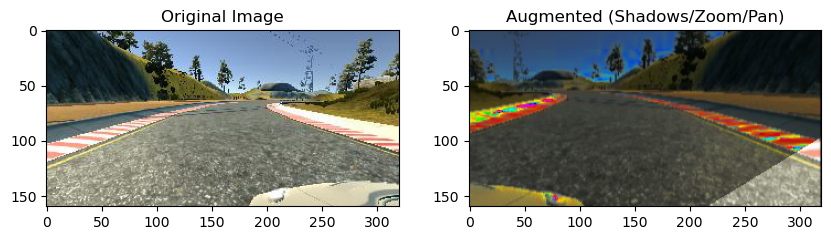

In [ ]:
# Augmentation Functions
def augmentImage(imgPath, steering):
    img = mpimg.imread(imgPath)
    
    # 1. PAN
    if np.random.rand() < 0.5:
        pan = iaa.Affine(translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)})
        img = pan.augment_image(img)
    
    # 2. ZOOM
    if np.random.rand() < 0.5:
        zoom = iaa.Affine(scale=(1, 1.2))
        img = zoom.augment_image(img)
        
    # 3. BRIGHTNESS
    if np.random.rand() < 0.5:
        brightness = iaa.Multiply((0.5, 1.2))
        img = brightness.augment_image(img)
        
    # 4. FLIP
    if np.random.rand() < 0.5:
        img = cv2.flip(img, 1)
        steering = -steering
        
    # 5. RANDOM SHADOW (The Generalizer)
    if np.random.rand() < 0.5:
        h, w = img.shape[0], img.shape[1]
        top_y = 320 * np.random.uniform()
        top_x = 0
        bot_x = w
        bot_y = 320 * np.random.uniform()
        image_hls = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)
        shadow_mask = 0 * image_hls[:, :, 1]
        X_m = np.mgrid[0:img.shape[0], 0:img.shape[1]][1]
        Y_m = np.mgrid[0:img.shape[0], 0:img.shape[1]][0]
        mask = np.zeros_like(X_m)
        if np.random.rand() > 0.5:
            mask[(Y_m - top_y) * (bot_x - top_x) - (bot_y - top_y) * (X_m - top_x) > 0] = 1
        else:
            mask[(Y_m - top_y) * (bot_x - top_x) - (bot_y - top_y) * (X_m - top_x) < 0] = 1
        
        if np.random.rand() > 0.5:
            image_hls[:, :, 1][mask == 1] = image_hls[:, :, 1][mask == 1] * 0.5
        else:
            image_hls[:, :, 1][mask == 0] = image_hls[:, :, 1][mask == 0] * 0.5
        img = cv2.cvtColor(image_hls, cv2.COLOR_HLS2RGB)
        
    return img, steering

# --- DEMO: Show Augmented Image ---
index = random.randint(0, len(imagesPath) - 1)
original_img = mpimg.imread(imagesPath[index])
augmented_img, _ = augmentImage(imagesPath[index], steerings[index])

f, axarr = plt.subplots(1, 2, figsize=(10, 5))
axarr[0].imshow(original_img)
axarr[0].set_title('Original Image')
axarr[1].imshow(augmented_img)
axarr[1].set_title('Augmented (Shadows/Zoom/Pan)')
plt.show()

## Step 5 : Preprocessing & Batch Generator

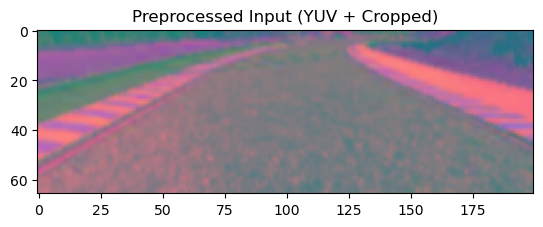

In [ ]:
# Preprocessing & Generators
def preProcessing(img):
    img = img[60:135,:,:] # Crop hood and sky
    img = cv2.cvtColor(img, cv2.COLOR_RGB2YUV) # NVIDIA Standard
    img = cv2.GaussianBlur(img, (3, 3), 0)
    img = cv2.resize(img, (200, 66))
    img = img / 255
    return img

def batchGen(imagesPath, steeringList, batchSize, trainFlag):
    while True:
        imgBatch = []
        steeringBatch = []
        
        for i in range(batchSize):
            index = random.randint(0, len(imagesPath) - 1)
            if trainFlag:
                img, steering = augmentImage(imagesPath[index], steeringList[index])
            else:
                img = mpimg.imread(imagesPath[index])
                steering = steeringList[index]
            
            img = preProcessing(img)
            imgBatch.append(img)
            steeringBatch.append(steering)
        yield (np.asarray(imgBatch), np.asarray(steeringBatch))

# Demo Preprocessing
preprocessed_img = preProcessing(mpimg.imread(imagesPath[index]))
plt.imshow(preprocessed_img)
plt.title("Preprocessed Input (YUV + Cropped)")
plt.show()

## Step 6 : Model Architecture (NVIDIA)

In [ ]:
# NVIDIA Model Architecture
def createModel():
    model = Sequential()
    model.add(Input(shape=(66, 200, 3)))
    
    # Convolutional Layers (Feature Extraction)
    model.add(Convolution2D(24, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Convolution2D(36, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Convolution2D(48, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Convolution2D(64, (3, 3), activation='elu'))
    model.add(Convolution2D(64, (3, 3), activation='elu'))
    
    model.add(Flatten())
    
    # Fully Connected Layers (Decision Making)
    model.add(Dense(100, activation='elu'))
    model.add(Dropout(0.5)) # Regularization
    model.add(Dense(50, activation='elu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='elu'))
    model.add(Dense(1)) # Output: Steering Angle
    
    model.compile(Adam(learning_rate=1e-4), loss='mse')
    return model

model = createModel()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 31, 98, 24)        1824      
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 47, 36)        21636     
                                                                 
 conv2d_2 (Conv2D)           (None, 5, 22, 48)         43248     
                                                                 
 conv2d_3 (Conv2D)           (None, 3, 20, 64)         27712     
                                                                 
 conv2d_4 (Conv2D)           (None, 1, 18, 64)         36928     
                                                                 
 flatten (Flatten)           (None, 1152)              0         
                                                                 
 dense (Dense)               (None, 100)               1

#  Step 7: Training the Model

In [ ]:
"""
# Training Configuration & Execution

# 1. Hyperparameters
batch_size = 128
epochs = 30
steps_per_epoch = len(xTrain) // batch_size
validation_steps = len(xVal) // batch_size

# 2. Callbacks (The "Smart" Training Tools)
# Checkpoint: Saves the model only when it improves
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "model_notebook_best.h5", 
    monitor='val_loss', 
    save_best_only=True, 
    mode='min', 
    verbose=1
)

# Early Stopping: Stops if no improvement for 7 epochs
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True, 
    verbose=1
)

# Reduce LR: Slows down learning when we get close to the solution
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

print(f"Starting Training with {steps_per_epoch} steps per epoch...")

# 3. Run Training
history = model.fit(
    batchGen(xTrain, yTrain, batch_size, 1),
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=batchGen(xVal, yVal, batch_size, 0),
    validation_steps=validation_steps,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

# 4. Save Final Model
model.save('model_notebook_final.h5')
print("Training Complete & Model Saved.")
"""

Epoch 1/10
142/300 [=============>................] - ETA: 1:08 - loss: 0.2724

# Step 8: Result Analysis

In [ ]:
# Plotting Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], linewidth=2)
plt.plot(history.history['val_loss'], linewidth=2)
plt.legend(['Training', 'Validation'])
plt.title('Model Loss (MSE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid(True)
plt.show()